# Exploratory Data Analysis on Retail Sales Dataset
## Author: Gaurvi Miglani
## Tools used: Python | Pandas | Numpy | Matplotlib | Seaborn | Jupyter Notebook
## Objective:
The objective of this project is to analyze retail sales data, identify trends, patterns, profitability drivers, and generate business insights 
through exploratory data analysis.
## Business Questions:
1. Which category generates the highest sales?
2. Which category generates the highest profit?
3. Which region contributes the most revenue?
4. How do discounts affect profitability?
5. Which sub-categories generate losses?
6. Are there significant relationships among sales, profit, discount, and quantity?
7. Are there outliers present in the sales data?
## Project Summary:
This project analyzes retail sales data using python to extract meaningful business insights through data cleaning, visualization, and statistical analysis.

## Import Required Libraries
The required Python libraries are imported for data manipulation, analysis, and visualization.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("libraries loades successfully!")

libraries loades successfully!


## Data Laoding:
The dataset is loaded into a Pandas DataFrame and the first few records are displayed to understand its structure.

In [3]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\CA Aman\Desktop\SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Dataset Overview:
This step helps understand:
- Number of rows and columns
- Data types
- Non-null values
- Overall dataset structure

In [4]:
df.shape

(9994, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


## Data Understanding
The dataset contains both numerical and categorical variables.

Numerical Variables:

- Sales
- Profit
- Quantity
- Discount

Categorical Variables:

- Category
- Sub-Category
- Region

The data types were verified to ensure accurate analysis and visualization.

## Data Cleaning:
Missing values can affect analysis and lead to incorrect conclusions. Therefore, the dataset is checked for null values.

In [6]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

## Duplicate Record Analysis
The dataset was checked for duplicate records to ensure data quality and avoid biased results.

In [4]:
df.duplicated().sum()

np.int64(17)

### Observation
A total of 17 duplicate records were identified in the dataset. Duplicate records can affect analysis results by counting the same transaction 
multiple times.Therefore, these records were removed before proceeding with further analysis.

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

### Action Taken
Duplicate records were successfully removed from the dataset to improve data quality and ensure accurate analysis.

## Step 5: Statistical Summary
Descriptive statistics provide information about:
- Mean
- Minimum
- Maximum
- Standard deviation
- Distribution of Sales and Profit

In [8]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [9]:
df[['Sales','Profit']].describe()

,Sales,Profit
count,9977.000000,9977.00000
mean,230.148902,28.69013
std,623.721409,234.45784
min,0.444000,-6599.97800
25%,17.300000,1.72620
50%,54.816000,8.67100
75%,209.970000,29.37200
max,22638.480000,8399.97600


### Statistical Summary - Observation

1. The dataset contains 9,977 records after removing duplicate entries.
2. The average Sales value is approximately 230.15, while the average Profit value is 28.69.
3. The standard deviation of Sales (623.72) and Profit (234.46) is relatively high, indicating considerable variation across transactions.
4. The minimum Profit value is -6599.98, showing that some transactions resulted in significant losses.
5. The maximum Sales value (22638.48) is much higher than the average Sales value, suggesting the presence of high-value transactions and potential
outliers.
6. The statistical summary indicates that Sales and Profit are not evenly distributed and require further analysis through visualizations and outlier
detection techniques.

## Overall Business Performance:
The total sales and total profit are calculated to understand overall business performance.

In [8]:
df['Sales'].sum()

np.float64(2297200.8603)

In [9]:
df['Profit'].sum()

np.float64(286397.0217)

# Exploratory Data Analysis (EDA)
Performed detailed analysis of sales, profit, discount, category and region to identify trends and patterns. 

## Category-wise Sales Analysis:
This analysis identifies which product category contributes the highest sales revenue.

In [10]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

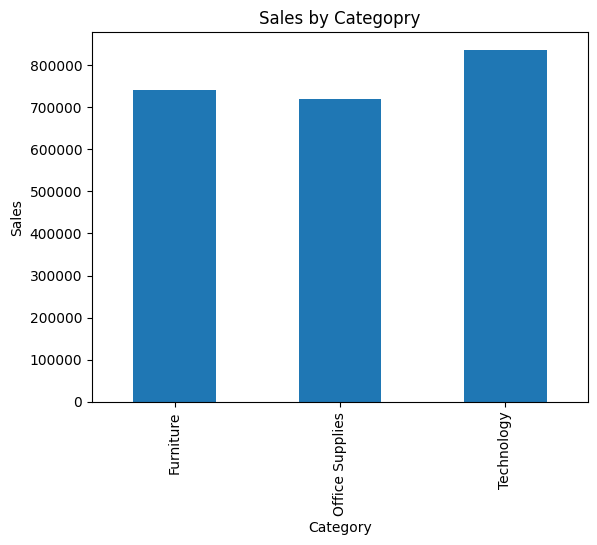

In [13]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Categopry')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

### Insight

-Technology has the highest total sales (~$750K).

-Office Supplies has the lowest sales (~$660K) among the three categories.

-All three categories are relatively balanced, with no extreme outlier.

## Category-wise Profit Analysis:
This analysis evaluates the profitability of each product category.

In [12]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

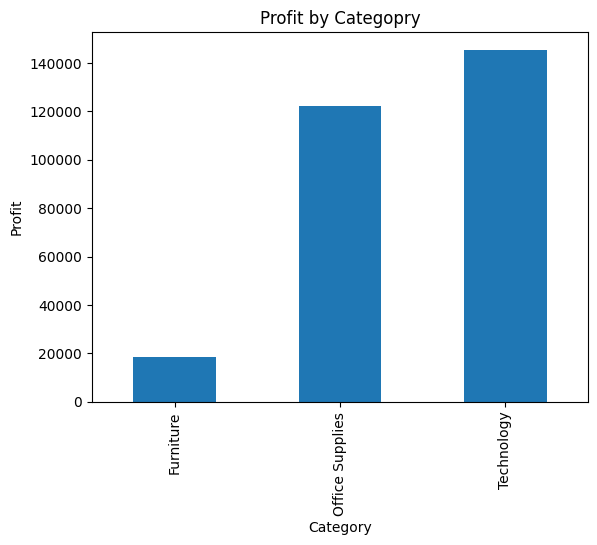

In [14]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Categopry')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

### Insight

-Technology category generated the highest profit contribution.

-Furniture is a high revenue but low margin category.

## Regional Sales Analysis:
This analysis helps identify high-performing regions in terms of revenue generation.

In [14]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

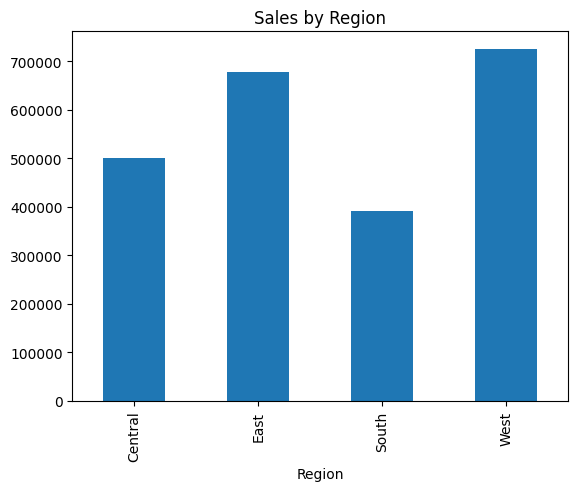

In [15]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Region')
plt.show()

### Insight
The West region recorded the highest sales among all regions.

## Regional Profit Analysis:
Profitability is analyzed across different geographical regions.

In [16]:
df.groupby('Region')['Profit'].sum()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

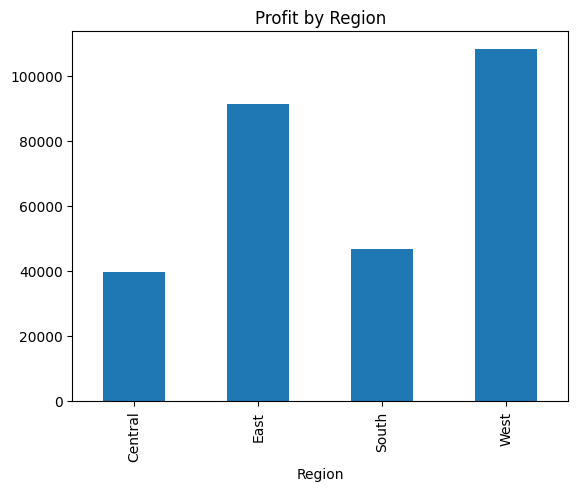

In [16]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Region')
plt.show()

### Insight
The West region recorded the highest profit, indicating strong business performance in that region.

## Sub-Category Analysis:
Sub-category analysis helps identify the best-selling and most profitable products.

### Sub-Category Sales

In [17]:
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

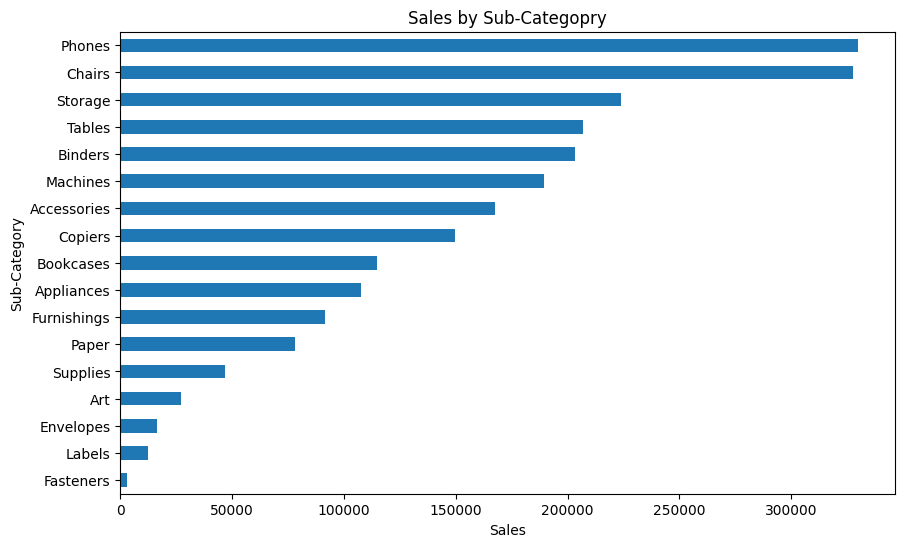

In [19]:
df.groupby('Sub-Category')['Sales'].sum().sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Sales by Sub-Categopry')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.show()

### Insight
Phones, chairs and storage are the top 3 sub-categories generated the highest sales revenue among all sub-categories, indicating strong customer demand. This suggests that phone-related products are a major contributor to overall business sales performance. Fasteners, labels and envelopes are the lowest sellers

### Sub-Category Profit analysis

In [19]:
df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Name: Profit, dtype: float64

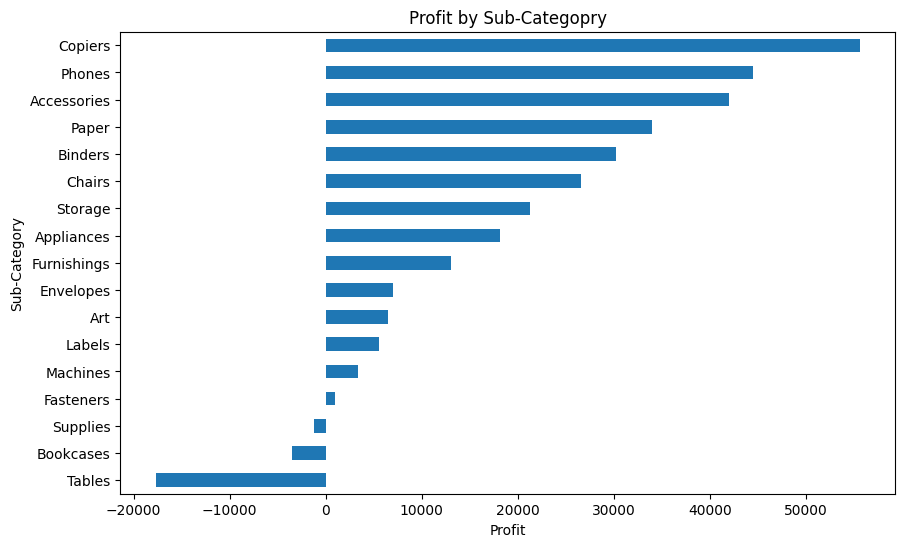

In [20]:
df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='barh',figsize=(10,6))
plt.title('Profit by Sub-Categopry')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.show()

### Insight
Copiers and phones are the most profitable sub-category, while Tables and bookcases generated highest losses. Machines have near zero profit despite high sales.This suggests the business should focus on profitable products and review pricing, discounts, or costs associated with loss-making products.

## Loss-Making Product Sub-Categories
This analysis identifies sub-categories that contribute negative profit and may require business attention.

In [20]:
df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Accessories     -930.6265
Fasteners        -33.1952
Name: Profit, dtype: float64

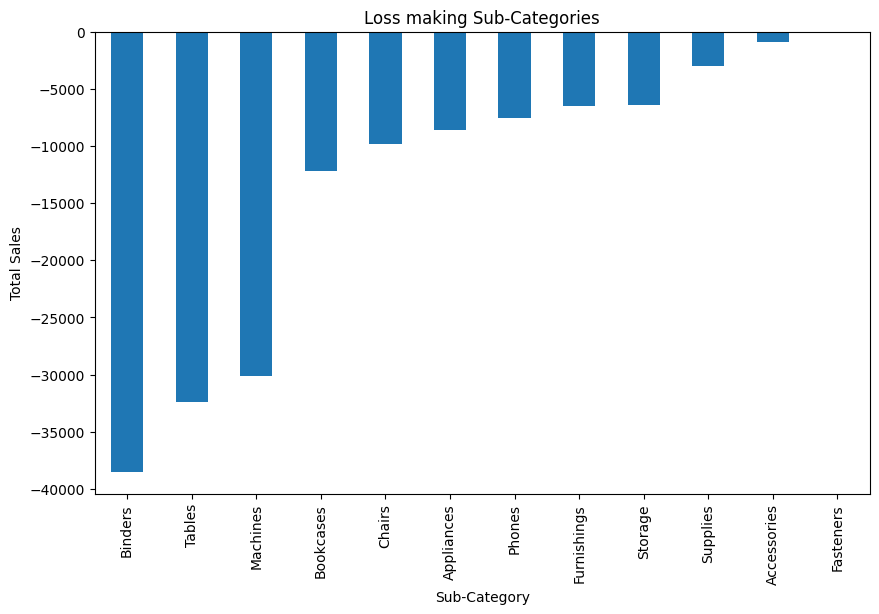

In [22]:
df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='bar',figsize=(10,6))
plt.title('Loss making Sub-Categories')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.show()

### Insight

The loss analysis identified several sub-categories that negatively impacted overall profitability.
- Binders recorded the highest loss, with a total loss of approximately $38,510.50.
  
- Tables generated the second-highest loss, with losses of approximately $32,412.15.

  
- Other sub-categories also contributed to losses, but at a lower magnitude.

- Fasteners recorded the smallest loss, with a total loss of approximately $33.20.

- The significant losses in Binders and Tables indicate a need to review pricing strategies, discount policies, and operational costs for these products.

This analysis helps identify areas where business improvements can be made to increase overall profitability.

## Discount Impact Analysis:
The relationship between discount and profit is examined to understand whether discounts affect profitability.

### Average Profit by Discount Level

In [23]:
df.groupby('Discount')['Profit'].mean()

Discount
0.00     67.024108
0.10     96.055074
0.15     27.288298
0.20     24.721217
0.30    -45.828401
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -102.116395
Name: Profit, dtype: float64

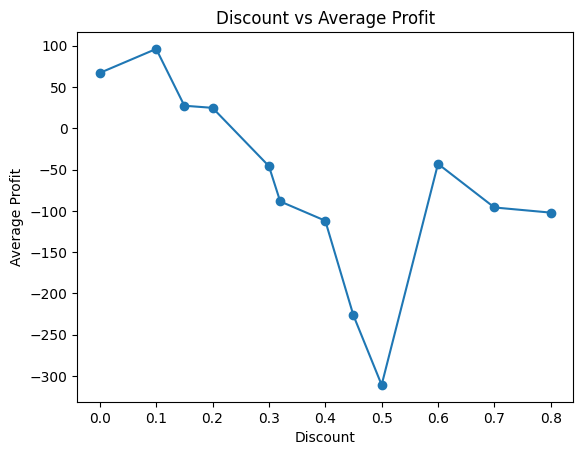

In [25]:
df.groupby('Discount')['Profit'].mean().plot(kind='line', marker='o')
plt.title('Discount vs Average Profit')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.show()

The line chart shows how average profit changes across different discount levels. it provides a clearer view of the overall trend compared to the 
transaction-level scatter plot.

### Discount vs Profit(Transaction-Level Analysis)

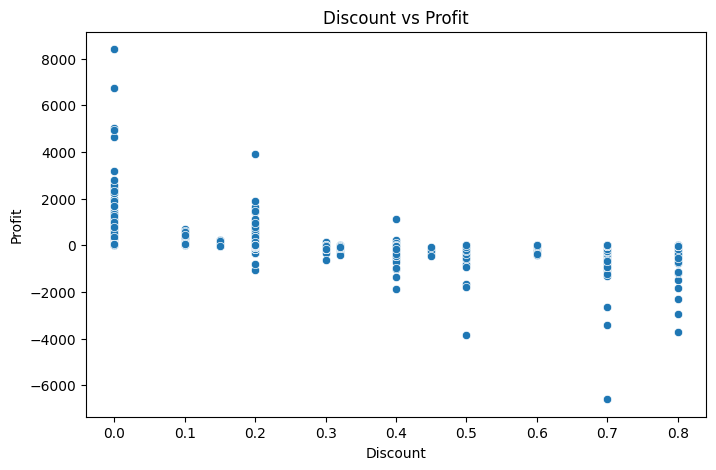

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)
plt.title("Discount vs Profit")
plt.show()

The scatter plot visualizes the relationship between discount and profit for individual transactions, it helps identify patterns, outliers, and the 
overall direction of the relationship.

### Insight

-Most profitable transactions occur at 0–10% discount.

-As discount levels rise (0.4–0.8), profit spreads into heavy negative territory.

-Confirms that aggressive discounting destroys profitability at the transaction level.

# Correlation Analysis:
Correlation analysis is performed to identify relationships between numerical variables.

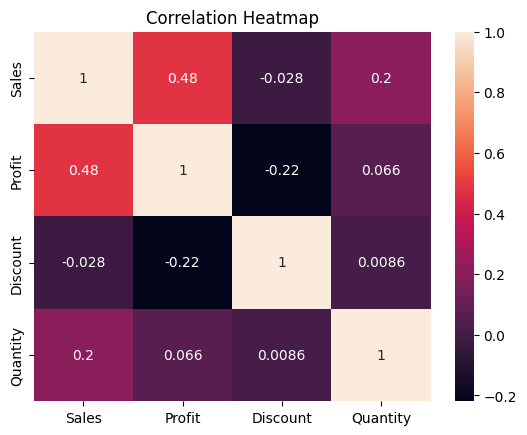

In [22]:
corr = df[['Sales','Profit','Discount','Quantity']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Insight

-Sales & Profit: 0.48 — moderate positive correlation (higher sales tend to bring more profit).

-Discount & Profit: –0.22 — negative correlation (more discount = less profit).

-Discount & Sales: –0.028 — nearly zero (discounts don't significantly boost sales volume).

-Quantity has very weak correlation with all other variables.

# Outlier Detection using IQR Method

In [23]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Sales'] < lower_bound) |
              (df['Sales'] > upper_bound)]
print("Number of outliers:", len(outliers))

Number of outliers: 1167


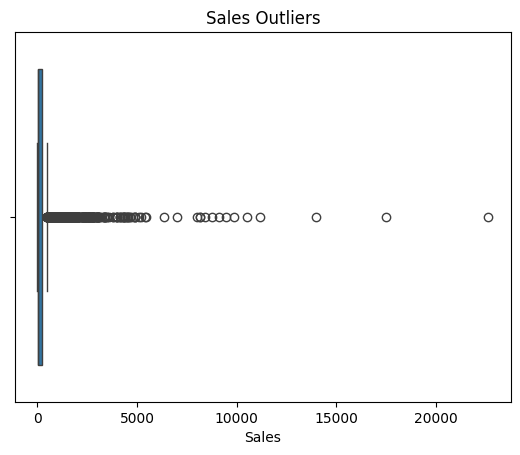

In [24]:
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

### Insight

-Most sales are concentrated below $2,000.

-Several high-value outliers exist beyond $10,000–$20,000.

-The distribution is highly right-skewed — a few large transactions drive a disproportionate share of revenue.

# Statistical Validation

In [25]:
!pip install scipy

In [26]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(df['Discount'], df['Profit'])
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.21948745637176847
P-value: 2.7022944361957867e-109


Hypothesis-
H0: Discount has no impact on Profit.
H1: Discount impacts Profit.

Interpretation-
If p-value < 0.05, reject H0 and conclude that discount significantly affects profit.

# Business KPI Dashboard

The purpose of this dashboard is to summarize the key business performance indicators in a single view. It helps in understanding overall sales 
performance, profitability, discount behavior, and order volume.

### Key Metrics Included

- Total Sales: Overall revenue generated by the business  
- Total Profit: Net profit after costs  
- Average Discount: Average discount offered across transactions  
- Total Orders: Total number of transactions in the dataset

In [29]:
df.columns = df.columns.str.strip()

In [30]:
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]
profit_col = [c for c in df.columns if 'profit' in c.lower()][0]
discount_col = [c for c in df.columns if 'discount' in c.lower()][0]

In [31]:
total_sales = df[sales_col].sum()
total_profit = df[profit_col].sum()
avg_discount = df[discount_col].mean()
total_orders = df.shape[0]

print("===== BUSINESS DASHBOARD =====")
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Average Discount:", round(avg_discount, 2))
print("Total Orders:", total_orders)

===== BUSINESS DASHBOARD =====
Total Sales: 2296195.59
Total Profit: 286241.42
Average Discount: 0.16
Total Orders: 9977


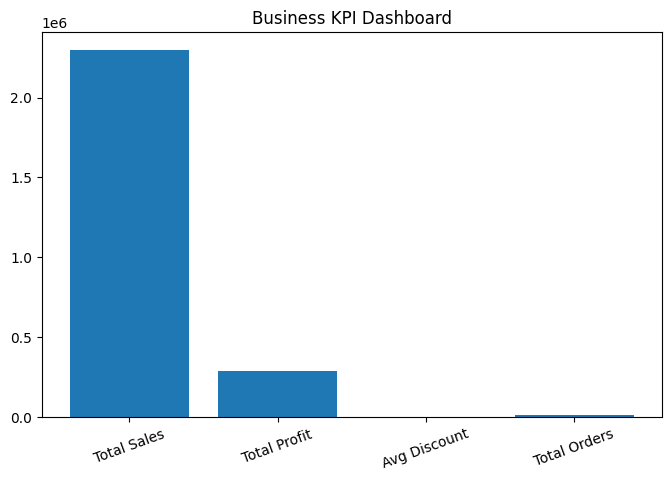

In [32]:
import matplotlib.pyplot as plt

metrics = ['Total Sales', 'Total Profit', 'Avg Discount', 'Total Orders']
values = [total_sales, total_profit, avg_discount, total_orders]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)

plt.title("Business KPI Dashboard")
plt.xticks(rotation=20)
plt.show()

# Key Findings
1) Technology is the star category — highest sales AND highest profit.
2) Furniture is a profit trap — near-equal sales to Technology but nearly 8× less profit.
3) Discounts are hurting the business — they don't increase sales volume but dramatically reduce profit margins.
4) West and East regions outperform Central and South in both sales and profit.
5) Tables, Binders, and Machines are loss-making despite decent sales figures.
6) Copiers and Phones are high-value, high-profit sub-categories worth prioritizing.
7) Sales data is heavily skewed — a small number of high-value orders account for a large portion of revenue.

# Business Recommendation
1) Review Furniture pricing & costs — audit supply chain and production costs; consider discontinuing low-margin furniture lines.
2) Cap discounts at 20% — data clearly shows profit turns negative beyond this threshold; implement discount approval policies.
3) Prioritize Technology category — invest in inventory, marketing, and sales push for Phones, Copiers, and Accessories.
4) Investigate Tables & Binders losses — either reprice them, reduce discounts on these items specifically, or phase them out.
5) Focus growth efforts on West & East — these regions yield the best ROI; analyze what's working there and replicate in South and Central.
6) Develop South region strategy — it lags significantly in both sales and profit; consider targeted campaigns or new distribution.
7) Protect high-value customers — the outlier transactions (>$10K sales) are critical; identify and retain these accounts with dedicated account management.

# Conclusion
This Exploratory Data Analysis (EDA) project on retail sales data successfully transformed raw data into meaningful business insights using Python-based data analysis techniques.
The analysis revealed that the Technology category is the strongest contributor to revenue, while Copiers emerged as the most profitable sub-category. On the other hand, product segments like Tables and Binders were identified as major loss-making areas, highlighting the need for strategic improvement in pricing and cost management.
Regional analysis showed that the West region performed significantly better in terms of both sales and profit, indicating strong market potential in that area. Additionally, the study found a clear negative relationship between discounts and profit, suggesting that excessive discounting can reduce overall profitability.
Through data cleaning, visualization, statistical analysis, and correlation studies, this project provided actionable insights that can support better business decision-making.
Overall, this analysis demonstrates how data-driven strategies can help organizations optimize performance, improve profitability, and make informed business decisions.